In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('Telco_customer_churn.csv')

# Telco Customer Churn Analysis

## Business Problem
A telecom company is losing customers to churn, which is more costly than 
retaining existing ones. This analysis identifies which customer segments 
are most likely to churn and what factors drive that behaviour, so the 
business can prioritise retention efforts toward at risk customers.

**Goals:**
1. Quantify the overall churn rate and identify the high risk segments
2. Identify the strongest drivers of churn
3. Estimate the revenue impact of churn
4. Provide actionable retention recommendations

**Tools:** Python (pandas, numpy, matplotlib, seaborn)

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
# total charges is str 
# check if any missing value
# inconsistent use of 0 1 in senior citizen

In [8]:
# total charges is str, convert into numeric 
# check if any missing values

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [9]:
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [10]:
# all brand new customers with 0 tenure and have not been billed yet
# instead of empty, fill with 0

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isnull().sum())

0


In [11]:
# check for inconsistent values

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                     'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                     'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in categorical_cols:
    print(col, ':', df[col].unique())

gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract : <StringArray>
['Month-to-month', 

In [12]:
# simplify no internet service to just no
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

for col in cols_to_fix:
    print(col, ':', df[col].unique())

MultipleLines : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies : <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [13]:
# Convert SeniorCitizen from 0 1
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


## Data Cleaning

- Converted `TotalCharges` from text to numeric and also found 11 missing values, 
  all belonging to customers with 0 months tenure (new customers not yet 
  billed). Filled these with 0 rather than the column average, since they 
  represent real "not yet applicable" cases, not data errors.
- Simplified "No internet service" / "No phone service" into "No" across 
  7 service columns, since they're functionally equivalent to the customers who 
  don't use this service.
- Converted `SeniorCitizen` from 0/1 to No/Yes for consistency with other 
  boolean columns.

In [14]:
# Feature engineering

In [15]:
# Group raw tenure months into readable buckets for easier analysis
bins = [0, 12, 24, 48, 72]
labels = ['0-1 yr', '1-2 yrs', '2-4 yrs', '4-6 yrs']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

print(df['tenure_group'].value_counts())

tenure_group
4-6 yrs    2239
0-1 yr     2186
2-4 yrs    1594
1-2 yrs    1024
Name: count, dtype: int64


In [16]:
# Count how many of the 6 add on services each customer subscribes to
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

print(df['num_services'].value_counts().sort_index())

num_services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


## Feature Engineering

- `tenure_group`: bucketed raw tenure (months) into 4 readable groups 
  (0-1 yr, 1-2 yrs, 2-4 yrs, 4-6 yrs) for easier grouping and visualisation.
- `num_services`: counted how many of the 6 add-on services (online 
  security, backup, device protection, tech support, streaming TV/movies) 
  each customer subscribes to, as a proxy for "stickiness"

In [17]:
# Calculate overall churn rate as a percentage
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Insight: Overall Churn Rate
26.5% of customers churned, i.e. roughly 1 in 4. This is the headline number 
for the business problem

In [18]:
# Check churn rate broken down by contract type
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100
print(churn_by_contract)

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64


### Insight: Contract Type is the Strongest Driver of Churn
Month-to-month customers churn at 42.7%. On the other hand, only 11.3% for one-year and 2.8% for two-year contracts. This is approx. 15 times gap between the extremes. Customers with no contractual commitment have far less friction to leaving.

In [19]:
# Check churn rate broken down by tenure group
churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True) * 100
print(churn_by_tenure)

tenure_group  Churn
0-1 yr        No       52.561757
              Yes      47.438243
1-2 yrs       No       71.289062
              Yes      28.710938
2-4 yrs       No       79.611041
              Yes      20.388959
4-6 yrs       No       90.486824
              Yes       9.513176
Name: proportion, dtype: float64


### Insight: Churn is Front-Loaded Early in the Customer Lifecycle
Churn is highest for new customers (47.4% in year one) and drops steadily to 9.5% by year 4-6. Retention risk is concentrated in the first year.

In [20]:
# Check churn rate broken down by number of add-on services
churn_by_services = df.groupby('num_services')['Churn'].value_counts(normalize=True) * 100
print(churn_by_services)

num_services  Churn
0             No       78.593961
              Yes      21.406039
1             No       54.244306
              Yes      45.755694
2             No       64.181994
              Yes      35.818006
3             No       72.629696
              Yes      27.370304
4             No       77.699531
              Yes      22.300469
5             No       87.565674
              Yes      12.434326
6             No       94.718310
              Yes       5.281690
Name: proportion, dtype: float64


In [21]:
# Check whether the num_services=0 group is mostly customers with no internet
print(df[df['num_services'] == 0]['InternetService'].value_counts())

InternetService
No             1526
Fiber optic     399
DSL             294
Name: count, dtype: int64


### Insight: More Services = Lower Churn (Among Internet Customers)
Churn drops steadily from 45.8% (1 service) to 5.3% (6 services). The apparent exception is 0 services showing lower churn (21.4%) and it turned out that the majority of that group are phone only customers with no internet at all, not customers who declined every add-on.

In [22]:
# Compare average monthly revenue and total monthly revenue at risk from churned customers
revenue_summary = df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'sum', 'count'])
print(revenue_summary)

            mean        sum  count
Churn                             
No     61.265124  316985.75   5174
Yes    74.441332  139130.85   1869


### Insight: Revenue Impact of Churn
 **Churned customers** had a **higher average monthly bill** compared to retained customers.

In [23]:
# Check churn rate broken down by payment method
churn_by_payment = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True) * 100
print(churn_by_payment)

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64


### Insight: Electronic Check Users Churn 3x More
Electronic check churns at 45.3%, compared to 15-19% for all other payment methods. This is a strong, independent risk signal.

In [24]:
# Set a clean, consistent look for all charts in this project
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

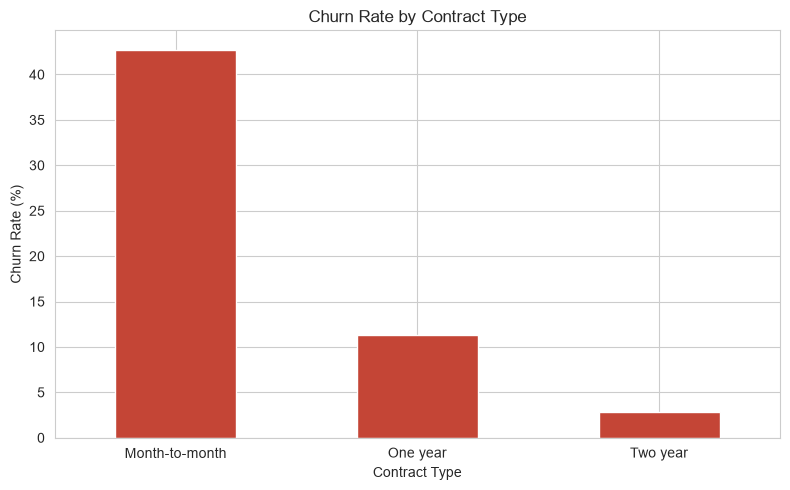

In [25]:
# Bar chart: churn rate by contract type
churn_contract_pct = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100

churn_contract_pct.plot(kind='bar', color='#C44536')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

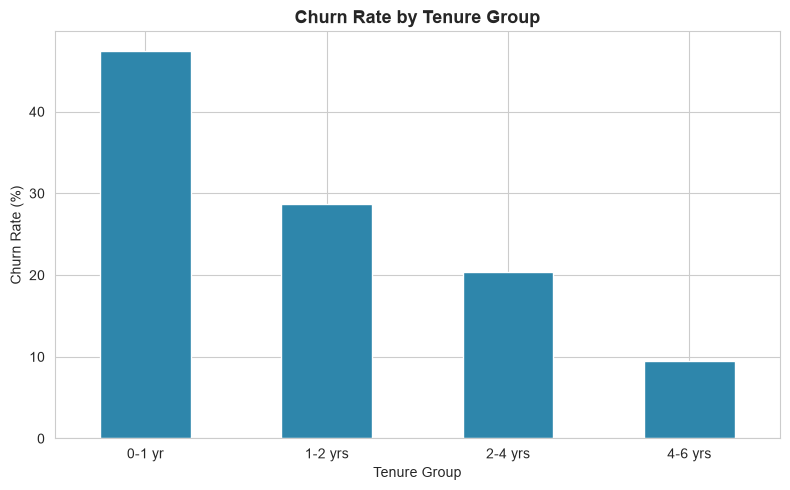

In [26]:
# Bar chart: churn rate by tenure group
churn_tenure_pct = df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100

churn_tenure_pct.plot(kind='bar', color='#2E86AB')
plt.title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

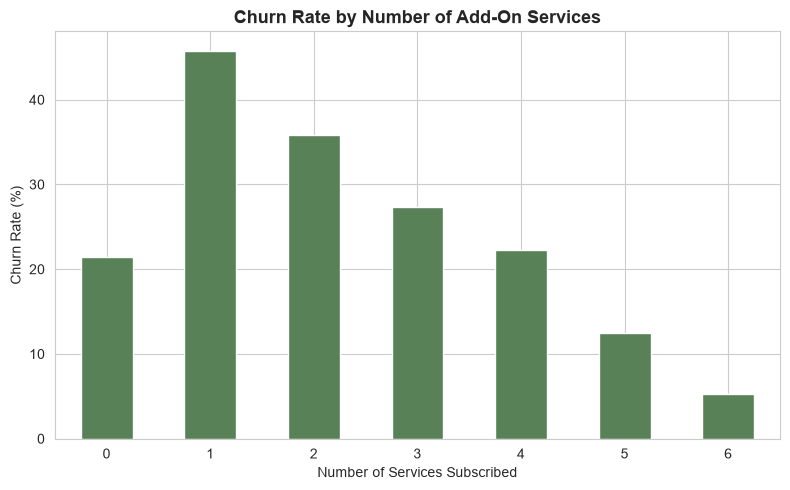

In [27]:
# Bar chart: churn rate by number of add-on services
churn_services_pct = df.groupby('num_services')['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100

churn_services_pct.plot(kind='bar', color='#588157')
plt.title('Churn Rate by Number of Add-On Services', fontsize=13, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Number of Services Subscribed')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

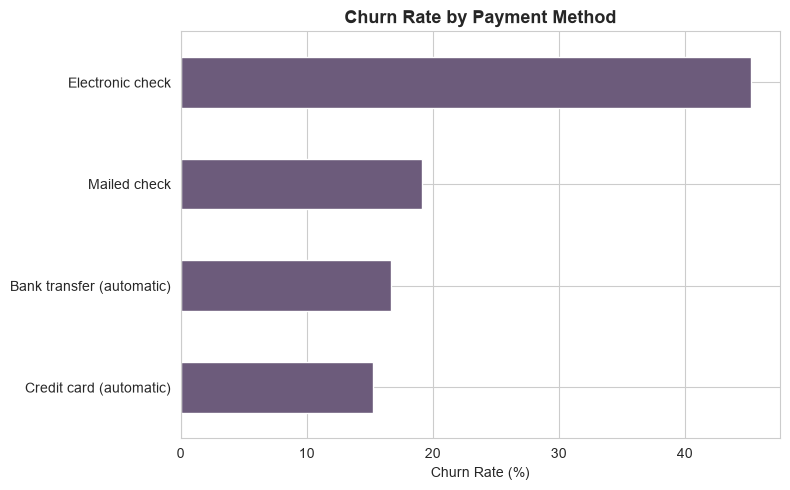

In [28]:
# Bar chart: churn rate by payment method (horizontal, since labels are long)
churn_payment_pct = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
churn_payment_pct = churn_payment_pct.sort_values(ascending=True)

churn_payment_pct.plot(kind='barh', color='#6C5B7B')
plt.title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

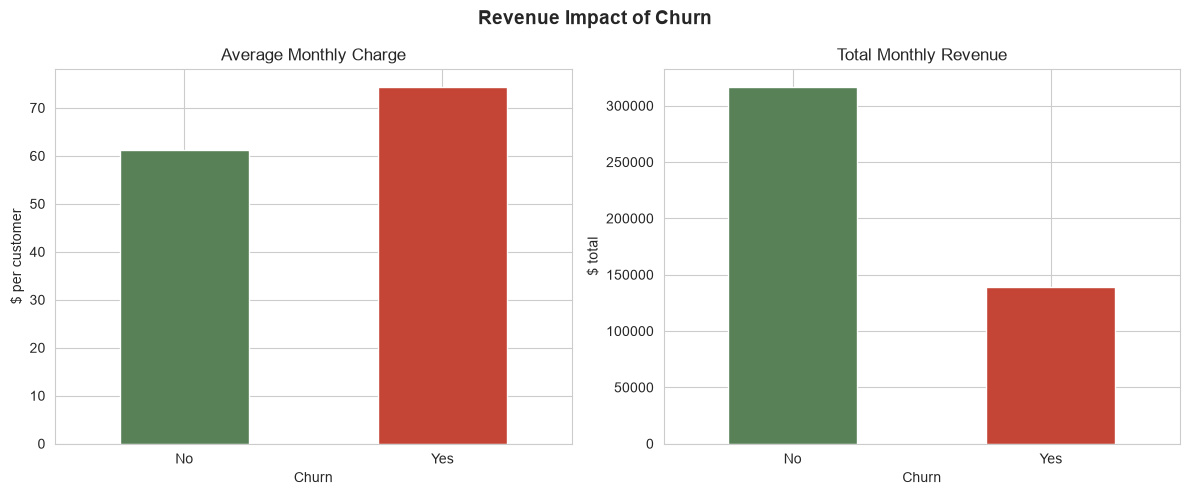

In [29]:
# Bar chart: average and total monthly revenue, churned vs retained
revenue_summary = df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'sum'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

revenue_summary['mean'].plot(kind='bar', ax=axes[0], color=['#588157', '#C44536'])
axes[0].set_title('Average Monthly Charge')
axes[0].set_ylabel('$ per customer')
axes[0].set_xlabel('Churn')
axes[0].tick_params(axis='x', rotation=0)

revenue_summary['sum'].plot(kind='bar', ax=axes[1], color=['#588157', '#C44536'])
axes[1].set_title('Total Monthly Revenue')
axes[1].set_ylabel('$ total')
axes[1].set_xlabel('Churn')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Revenue Impact of Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

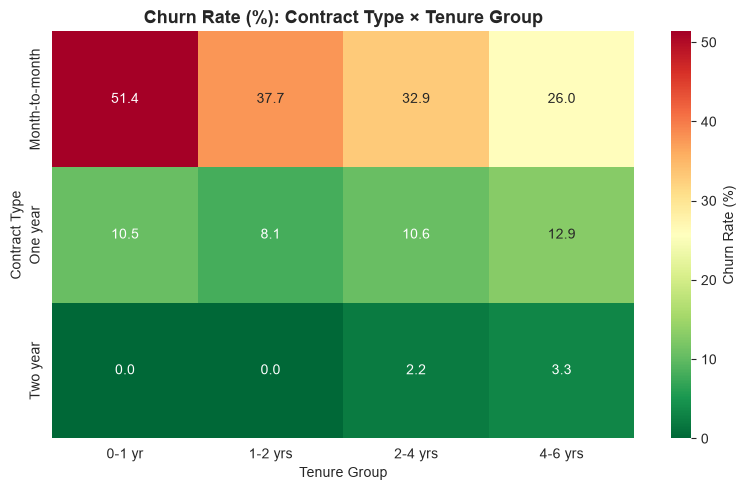

In [30]:
# Heatmap: churn rate across two dimensions at once (Contract x Tenure Group)
pivot = df.groupby(['Contract', 'tenure_group'], observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): Contract Type × Tenure Group', fontsize=13, fontweight='bold')
plt.ylabel('Contract Type')
plt.xlabel('Tenure Group')
plt.tight_layout()
plt.show()

### Insight: Contract and Tenure Compound Each Other
Month-to-month customers churn at 51.4%, the riskiest segment in the dataset, while two-year contract customers stay under 4% churn regardless
of tenure. 

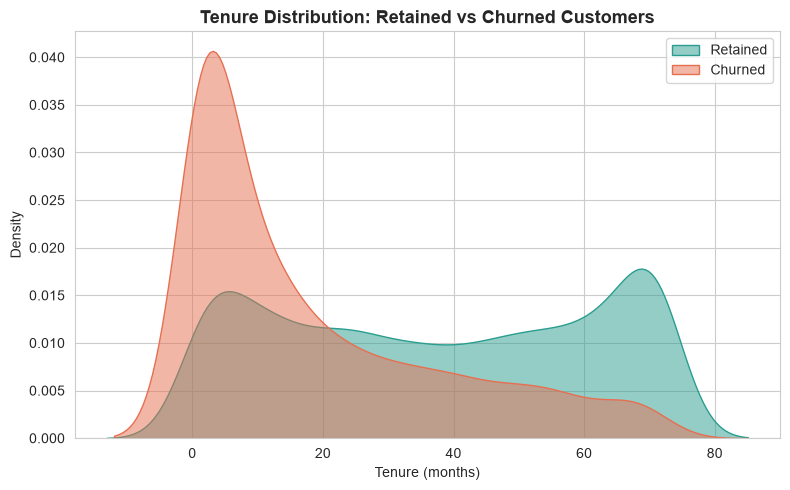

In [31]:
# Distribution plot: how tenure differs between churned and retained customers
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['Churn'] == 'No'], x='tenure', label='Retained', fill=True, color='#2A9D8F', alpha=0.5)
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='tenure', label='Churned', fill=True, color='#E76F51', alpha=0.5)

plt.title('Tenure Distribution: Retained vs Churned Customers', fontsize=13, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Insight: Churn Risk Spikes Early, Then Fades
The tenure distribution shows churned customers concentrated sharply around months 3-5, while retained customers are spread evenly and cluster again around year 5-6 (long-tenure base). The first 6 months is the critical retention window.

## Recommendations

1. **Prioritise contract conversion** incentivise month-to-month customers, especially in their first 6 months, to move to longer contracts.
2. **Build a first-90-days retention program** with proactive onboarding and early check-ins to catch at-risk customers before they churn.
3. **Encourage add-on bundling** for internet customers to increase stickiness.
4. **Investigate the electronic check segment** and incentivise a switch to automatic payment methods.